In [1]:
# libraries for data loading and system/path settings
import json
import sys
import gc
import warnings
import os
from pathlib import Path

# libraries for model building and training
from sklearn.model_selection import train_test_split
from transformers import AutoTokenizer, logging
import torch
from torch.utils.data import Dataset
import optuna
from functools import partial

# set path to project root and import custom classes and functions
base_path = Path.cwd() / "../../"
sys.path.append(str(base_path.resolve()))
from utils.classification import EarlyStopping, tune_bert_stance_optuna
from utils.evaluation import cross_validation
from utils.visualizations import plot_losses_f1

# global settings to suppress unproblematic warning messages
os.environ["TOKENIZERS_PARALLELISM"] = "false"
logging.set_verbosity_error()
warnings.filterwarnings("ignore", message="The sentencepiece tokenizer")

In [2]:
# load the data
with open("../../01_data/annotations_reduced.json", "r") as f:
    data = json.load(f)

# initialize dictionary for the sentiment classes
sent_dict = set()

# loop through all sentences
for task in data:
    if task["annotations"]:
        for annotation in task["annotations"]:
            label = annotation["tag"][3:]
            sent_dict.add(label)

# sort the tag dictionary
label_list = sorted(sent_dict)

# dictionaries that convert from id to tag and vice versa
label_to_id = {tag: i for i, tag in enumerate(label_list)}
id_to_label = {id: label for label, id in label_to_id.items()}

In [4]:
# get all data with annotations
data_with_annotations = []
for task in data:
    if task["annotations"]:
        data_with_annotations.append(task)

# split into training and test dataset
train_data, val_data = train_test_split(data_with_annotations, test_size=0.2, shuffle=True, random_state=42)

class StanceDataset(Dataset):
    def __init__(self, data, tokenizer, label2id, max_len=128):
        self.dataset = []
        for item in data:
            sentence = item["sentence"]
            for ann in item["annotations"]:
                span_text = ann["text"]
                label = label2id[ann["tag"][3:]]
                # combine sentence and target span
                encoded = tokenizer(
                    sentence,
                    span_text,
                    truncation=True,
                    padding="max_length",
                    max_length=max_len,
                    return_tensors="pt"
                )
                self.dataset.append({
                    "input_ids": encoded["input_ids"].squeeze(0),
                    "attention_mask": encoded["attention_mask"].squeeze(0),
                    "label": torch.tensor(label, dtype=torch.long)
                })
    
    def __len__(self):
        return len(self.dataset)
    
    def __getitem__(self, idx):
        return self.dataset[idx]

In [5]:
# hyperparameter tuning with TPE implemented via Optuna

# define the objective function whose output optuna tries to maximize
def objective(trial, model_name, train_dataset, val_dataset, label2id, id2label, device, early_stopper):

    # hyperparameter space in which optuna can search
    params = {
        "lr": trial.suggest_categorical("lr", [9e-6, 2e-5, 4e-5]),
        "batch_size": trial.suggest_categorical("batch_size", [8, 16, 32]),
        "weight_decay": trial.suggest_categorical("weight_decay", [0.01, 0.1, 0.3]),
        "epochs": trial.suggest_categorical("epochs", [2, 2, 2])
    }

    # train the model with these hyperparameters
    best_f1, best_epoch, train_losses, val_losses, f1_scores_train, f1_scores_val = tune_bert_stance_optuna(
        train_dataset=train_dataset,
        val_dataset=val_dataset,
        model_name=model_name,
        label2id=label2id,
        id2label=id2label,
        device=device,
        early_stopper=early_stopper,
        params=params
    )

    # besides parameters, save losses and f1-scores in the trial object
    trial.set_user_attr("best_epoch", best_epoch)
    trial.set_user_attr("train_losses", train_losses)
    trial.set_user_attr("val_losses", val_losses)
    trial.set_user_attr("f1_scores_train", f1_scores_train)
    trial.set_user_attr("f1_scores_val", f1_scores_val)

    return best_f1


# dictionary to save optimal paramaters
optimal_configs = {}

# number of trials, the device on which models should operate and the specific models to test
num_trials = 2
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
model_names = ["roberta-base", "bert-base-cased", "distilbert-base-cased", "microsoft/deberta-v3-base"]

# loop over the models
for model_name in model_names:

    print(f"\nStarting search for model: {model_name}")
    print("-"*200)

    # create a new optuna study, tokenizer fitting to the model as well as train and validation set
    study = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler())
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    train_dataset = StanceDataset(data=train_data, tokenizer=tokenizer, label2id=label_to_id, max_len=128)
    val_dataset = StanceDataset(data=val_data, tokenizer=tokenizer, label2id=label_to_id, max_len=128)

    # set model name for output path
    if model_name == "microsoft/deberta-v3-base":
        output_path = "model_saves/deberta.pt"
    else:
        output_path = f"model_saves/{model_name}.pt"

    # run the optimization loop
    study.optimize(
        partial(objective,
                model_name=model_name,
                train_dataset=train_dataset,
                val_dataset=val_dataset,
                label2id=label_to_id,
                id2label=id_to_label,
                device=device,
                early_stopper=EarlyStopping(patience=3, path=output_path, printoption=True)),
        n_trials=num_trials
    )

    # get the best trial and save optimal parameters
    best_trial = study.best_trial
    optimal_configs[model_name] = {
        "best_f1": best_trial.value,
        "best_params": best_trial.params,
        "best_epoch": best_trial.user_attrs["best_epoch"],
        "train_losses": best_trial.user_attrs["train_losses"],
        "val_losses": best_trial.user_attrs["val_losses"],
        "f1_scores_train": best_trial.user_attrs["f1_scores_train"],
        "f1_scores_val": best_trial.user_attrs["f1_scores_val"]
    }

    # clean all objects and empty cache for the next model
    del study, tokenizer, train_dataset, val_dataset
    gc.collect()
    torch.mps.empty_cache()

    print("-"*200)

[I 2025-11-06 11:28:39,856] A new study created in memory with name: no-name-91b8adbc-482b-463b-833d-77039af62657



Starting search for model: roberta-base
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

Trial with params: {'lr': 2e-05, 'batch_size': 8, 'weight_decay': 0.3, 'epochs': 2}
Epoch 1/2


Training: 100%|██████████| 30/30 [00:07<00:00,  3.78it/s, loss=0.845]


Average training loss: 0.9715


/Users/maxweiland/Desktop/SEDS/Master_Thesis/venv_thesis/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/maxweiland/Desktop/SEDS/Master_Thesis/venv_thesis/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/maxweiland/Desktop/SEDS/Master_Thesis/venv_thesis/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to

...

Epoch 2/2


Training: 100%|██████████| 8/8 [00:10<00:00,  1.34s/it, loss=0.993]


Average training loss: 0.9784


/Users/maxweiland/Desktop/SEDS/Master_Thesis/venv_thesis/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/maxweiland/Desktop/SEDS/Master_Thesis/venv_thesis/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/maxweiland/Desktop/SEDS/Master_Thesis/venv_thesis/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to

--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------


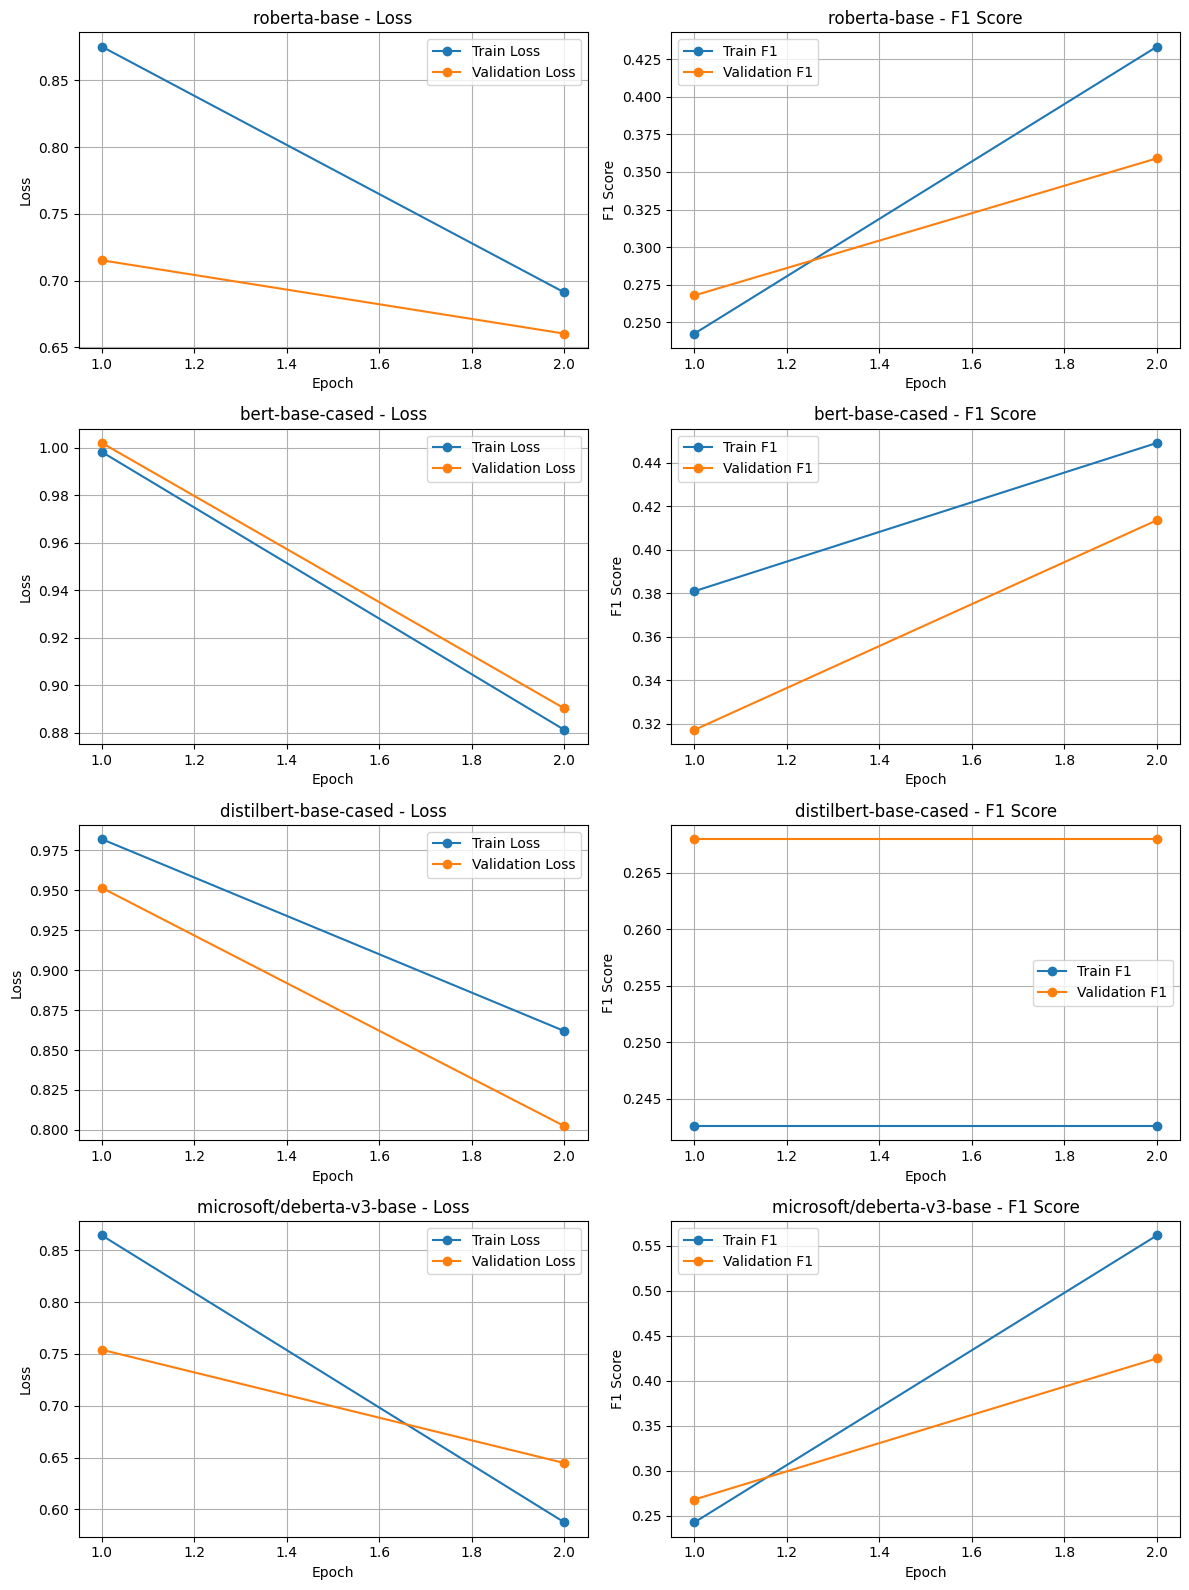

In [6]:
# plot the development of F1 scores and losses for the tuned models
plot_losses_f1(model_names, optimal_configs)

In [10]:
# apply cross validation to all models with their best hyperparameters
average_metrics = cross_validation(model_names=model_names, training_data=train_data, dataset_class=StanceDataset,
                                   label2id=label_to_id, id2label=id_to_label, num_folds=5, optimal_configurations=optimal_configs,
                                   classification_task="stance")

# export the cross-validation metrics
with open("eval_results/evaluation_metrics_bert.json", "w") as f:
    json.dump(average_metrics, f, indent=4)


Cross-validation for model roberta-base starts
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

Fold number: 1
Epoch 1/2


Training: 100%|██████████| 24/24 [00:06<00:00,  3.94it/s, loss=1.05] 


Average training loss: 0.9776
Epoch 2/2


Training: 100%|██████████| 24/24 [00:05<00:00,  4.18it/s, loss=0.898]


Average training loss: 0.8928


KeyError: 1